# Decision Tree vs. Random Forest — Stroke Risk Classification

Comparing a single, fully interpretable decision tree against a Random Forest ensemble on a public stroke-risk dataset, with a particular focus on what happens to "accuracy" once the target classes are heavily imbalanced.

- Minimal preprocessing and encoding of categorical features
- A cross-validated decision tree, visualized and interpreted node by node
- A Random Forest evaluated with the out-of-bag score
- Confusion matrices to check what each model actually gets wrong, not just its overall accuracy

## Load the data and minimal preprocessing

In [11]:
# Import tools to manipulate data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [12]:
# We can remove the first column as we dont need the id
df = df.iloc[:, 1:]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [13]:
# Transfor all categorical variables
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['ever_married'] = df['ever_married'].map({'No': 0, 'Yes': 1})
df['work_type'] = df['work_type'].map({'children': 0, 'Never_worked': 1, 'Govt_job': 2, 'Private': 3, 'Self-employed': 4})
df['Residence_type'] = df['Residence_type'].map({'Urban': 0, 'Rural': 1})
df['smoking_status'] = df['smoking_status'].map({'never smoked': 0, 'formerly smoked': 1, 'smokes': 2, 'Unknown': 3})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   float64
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   int64  
 5   work_type          5110 non-null   int64  
 6   Residence_type     5110 non-null   int64  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   int64  
 10  stroke             5110 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 439.3 KB


In [14]:
# As there are NaN in bmi we check
print (df['bmi'])
df.dropna(subset=['bmi'], inplace=True)
df.info()

0       36.6
1        NaN
2       32.5
3       34.4
4       24.0
        ... 
5105     NaN
5106    40.0
5107    30.6
5108    25.6
5109    26.2
Name: bmi, Length: 5110, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4908 non-null   float64
 1   age                4909 non-null   float64
 2   hypertension       4909 non-null   int64  
 3   heart_disease      4909 non-null   int64  
 4   ever_married       4909 non-null   int64  
 5   work_type          4909 non-null   int64  
 6   Residence_type     4909 non-null   int64  
 7   avg_glucose_level  4909 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     4909 non-null   int64  
 10  stroke             4909 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 460.2 KB


In [15]:
countna_gender=(df['gender']).isna().sum()
print(countna_gender)
count_females=(df['gender']).eq(1).sum()
print(count_females)
# As female (2897) is more common than male (2011) we impute this missing value with 1 (female)
(df['gender']) = (df['gender']).fillna(1)
df.info()

1
2897
<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4909 non-null   float64
 1   age                4909 non-null   float64
 2   hypertension       4909 non-null   int64  
 3   heart_disease      4909 non-null   int64  
 4   ever_married       4909 non-null   int64  
 5   work_type          4909 non-null   int64  
 6   Residence_type     4909 non-null   int64  
 7   avg_glucose_level  4909 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     4909 non-null   int64  
 10  stroke             4909 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 460.2 KB


In [16]:
# Separate features and labes (outcome)
# feature data in X
X = df.drop('stroke', axis=1)
# label data in y
y = df['stroke']

## Implement DT with cross-validation. Plot ONE tree and interpret it.

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

# CROSS VALIDATION
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# define a pipeline with standard scaler + knn
pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('dt', DecisionTreeClassifier())
])
# set the model hyperparameters
pipe.set_params(dt__criterion="gini", dt__max_depth=4)

scores = cross_val_score(pipe, X, y, cv=5)
scores

mean_accuracy = np.mean(scores)
print("Mean CV Accuracy:", mean_accuracy)


Accuracy: 0.9511201629327902
Mean CV Accuracy: 0.9559994269947744


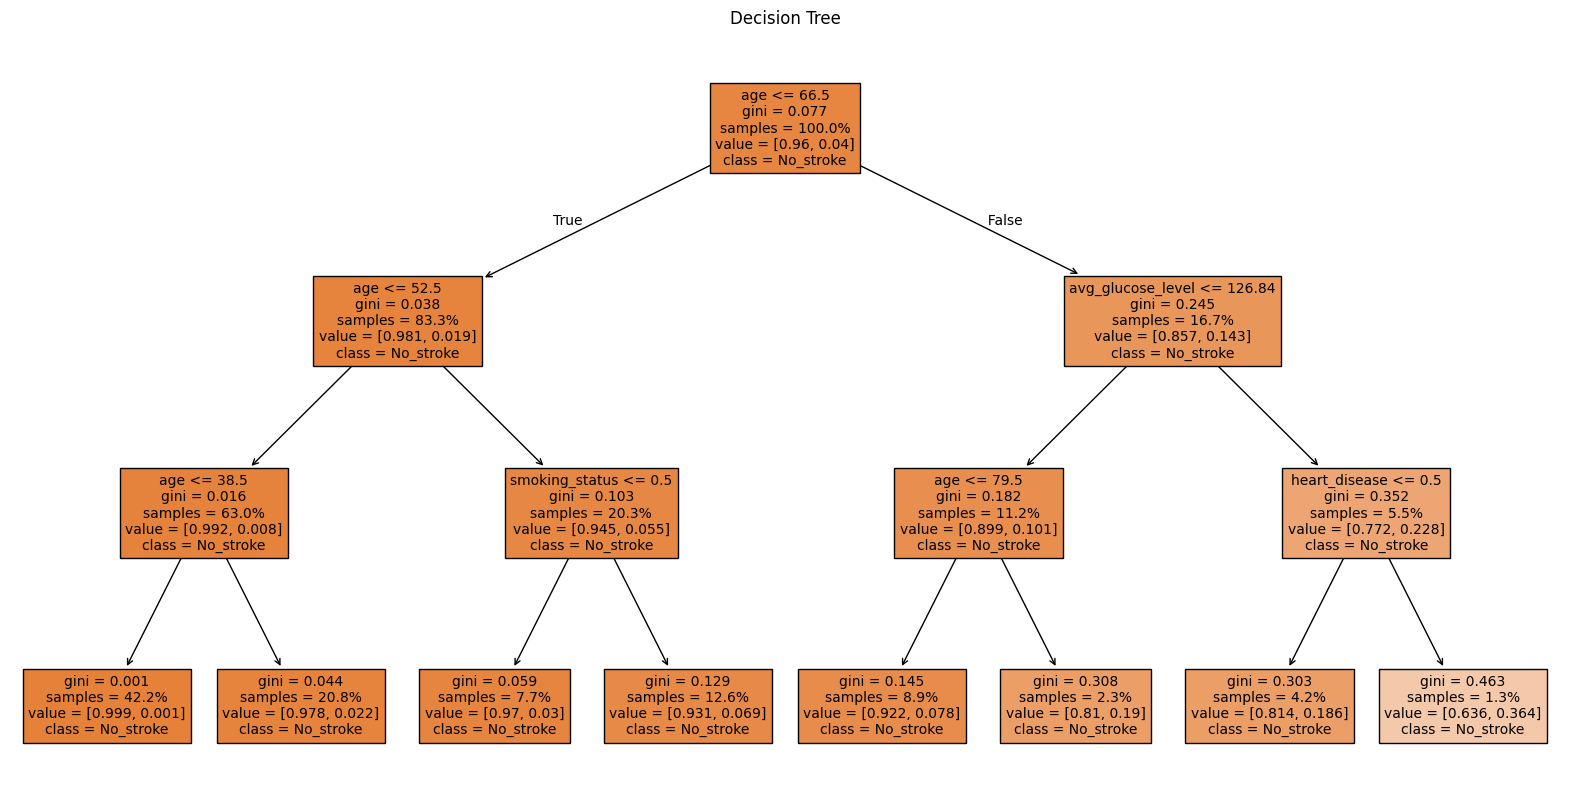

In [20]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No_stroke', 'Stroke'], proportion=True, filled=True, fontsize=10)
plt.title("Decision Tree")
plt.show()

# Interpretation: From left to right, the leaves goes from more pure to less
# pure, but, overall, the gini values are pretty low and so we might fall to
# assume that the model calssifies pretty well. Age seems to be a very important
# feature for classification as it is the root node and its also present in many
# decision nodes

## Evaluate overfitting

In [21]:
# calculate accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

# compare it with the train accuracy
y_train_pred_dt = dt_model.predict(X_train)
print("Accuracy:", accuracy_score(y_train, y_train_pred_dt))

# It seems that we didn't overfit the model as the values are very similar

Accuracy: 0.9511201629327902
Accuracy: 0.960128055878929


## Implement RF using oob score as test.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

from sklearn.ensemble import RandomForestClassifier # it is an ensemble method
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

## CROSS VALIDATION ##
# compare it with the train accuracy
y_train_pred_rf = dt_model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
# compare it with the OOB score
rf_model = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42, bootstrap=True)
rf_model.fit(X, y)
print("OOB Score:", rf_model.oob_score_)

# There is no overfitting

# REMEMBER: while a single accuracy score gives you an idea of how the model
# performed on a specific split, cross-validation (or OOB score for Random
# Forests) gives you a more reliable and generalizable measure of the model's
# performance by evaluating it on multiple subsets of the data. This helps in
# understanding how well your model is likely to perform on truly unseen data
# and in identifying potential overfitting.

Accuracy: 0.9517990495587237
Train Accuracy: 0.960128055878929
OOB Score: 0.9559991851700957


## Plot confusion matrices

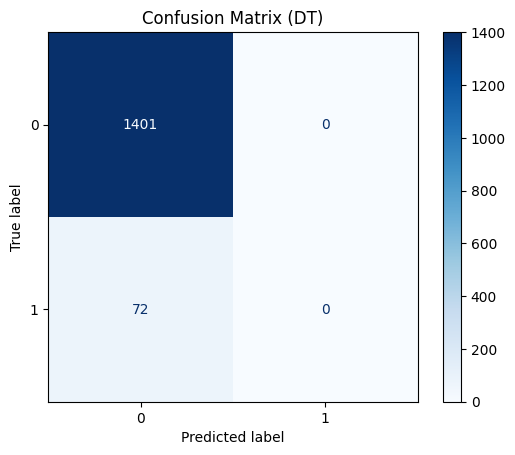

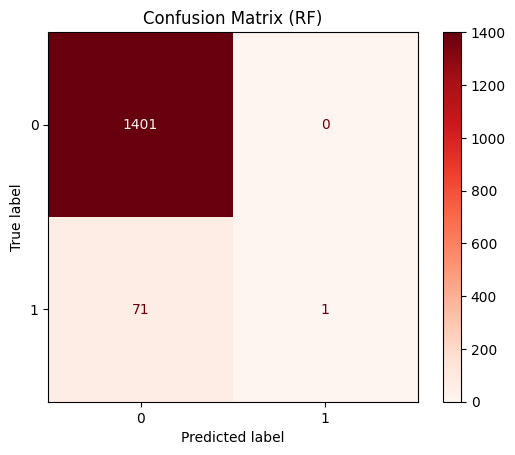

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix plot DT
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (DT)")
plt.show()


# Confusion matrix plot RF
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.title("Confusion Matrix (RF)")
plt.show()

## Interpret the results

In this specific exercise we did not scale the data, as in this way it could be more informative. Both models (DT and RF) perform very well, and they only present some false negatives. Their accuracy in both cases is pretty high (around 0.95) and we find no overfitting in any case. We could analyze other metrics but i think there is no need to in order to evaluate the fitting of the models.
